<a href="https://colab.research.google.com/github/ADRAKECROWDER/AIML2013-cv/blob/main/week1/lab1_EdgeDetectionBlurringKernels.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

The topic for this labv is edge detection and blurring filters in computer vision. The goal was to see how different filters change the way a computer reads an image by smoothing details or highlighting edges. I chose a Turks and Caicos beach image to go along with the theme for NLP.

In [6]:
# Run this cell first. If OpenCV isn't installed, uncomment the pip line.
# !pip install opencv-python-headless -q

import cv2
import numpy as np
import matplotlib.pyplot as plt
import urllib.request

# Display helper — use this throughout the lab
def show_images(images, titles, cols=3, figsize=(15, 5)):
    """Display a row of images with titles."""
    rows = (len(images) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(figsize[0], figsize[1] * rows))
    if rows == 1:
        axes = [axes] if cols == 1 else axes
    else:
        axes = axes.flatten()
    for i, (img, title) in enumerate(zip(images, titles)):
        if len(img.shape) == 2:  # grayscale
            axes[i].imshow(img, cmap='gray')
        else:  # color
            axes[i].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        axes[i].set_title(title, fontsize=10)
        axes[i].axis('off')
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')
    plt.tight_layout()
    plt.show()

This cell sets up the notebook and imports the tools needed for image processing. It includes the libraries for OpenCV, NumPy, and plotting.

In [ ]:
# Cell 2: Load your image
# Option A: Upload from your computer
# from google.colab import files
# uploaded = files.upload()
# filename = list(uploaded.keys())[0]
# img = cv2.imread(filename)

# Option B: Load from a URL (uncomment if you prefer)
import urllib.request

url = "https://upload.wikimedia.org/wikipedia/commons/1/14/Grace_bay%2C_Turks_and_Caicos_%2844250116614%29.jpg"
req = urllib.request.Request(
    url,
    headers={"User-Agent": "Mozilla/5.0"}
)
with urllib.request.urlopen(req) as response, open("sample.jpg", "wb") as out_file:
    out_file.write(response.read())

img = cv2.imread("sample.jpg")

# Inspect the original size
print(f"Original size: {img.shape[1]}x{img.shape[0]} pixels, {img.shape[2]} channels")
print(f"Dtype: {img.dtype}")     # uint8 (0-255)


This cell loads the image into the notebook using the URL option.

Resized to: 800x533 pixels


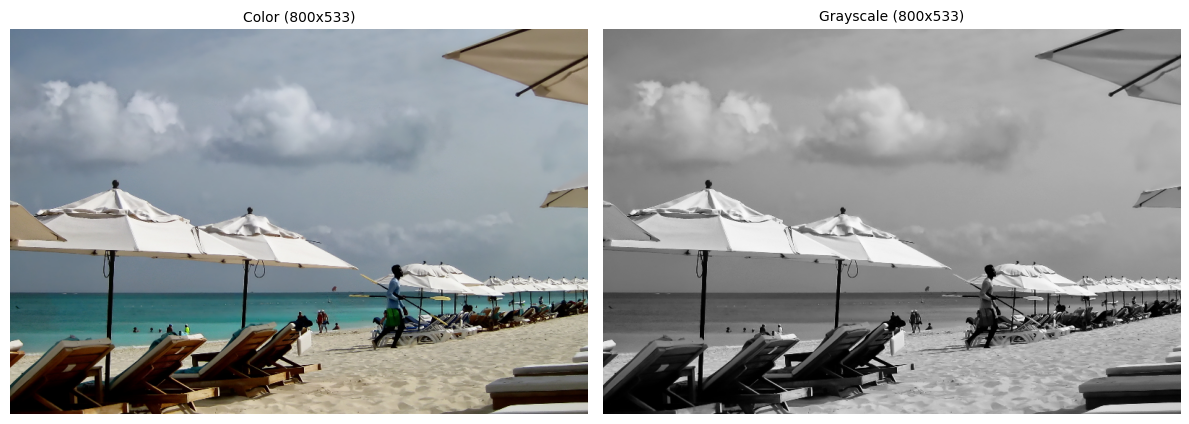

In [8]:
# Phone cameras produce images that are thousands of pixels wide.
# That's way more than we need and will make Colab slow.
# This resizes so the longest side is ~800px, keeping the aspect ratio.

max_dim = 800
h, w = img.shape[:2]
if max(h, w) > max_dim:
    scale = max_dim / max(h, w)
    img = cv2.resize(img, (int(w * scale), int(h * scale)))
    print(f"Resized to: {img.shape[1]}x{img.shape[0]} pixels")
else:
    print(f"Image is already {w}x{h} — no resize needed")

# Convert to grayscale — you'll need this for edge detection
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

show_images(
    [img, gray],
    [f"Color ({img.shape[1]}x{img.shape[0]})", f"Grayscale ({gray.shape[1]}x{gray.shape[0]})"],
    cols=2, figsize=(12, 5)
)

This is where the image is resized and turned into grayscale.

I chose a Grace Bay, Turks and Caicos beach image because it has clear structure for edge detection. The shoreline, horizon, umbrellas, chairs, and people all create visible edges, while the sky, water, and sand show smooth color gradients. The original image was 2200 pixels, and it was resized to 800 pixels. I expected the filters to pick up strong horizontal lines at the shoreline and horizon, plus smaller edges around the umbrellas, chairs, and people.

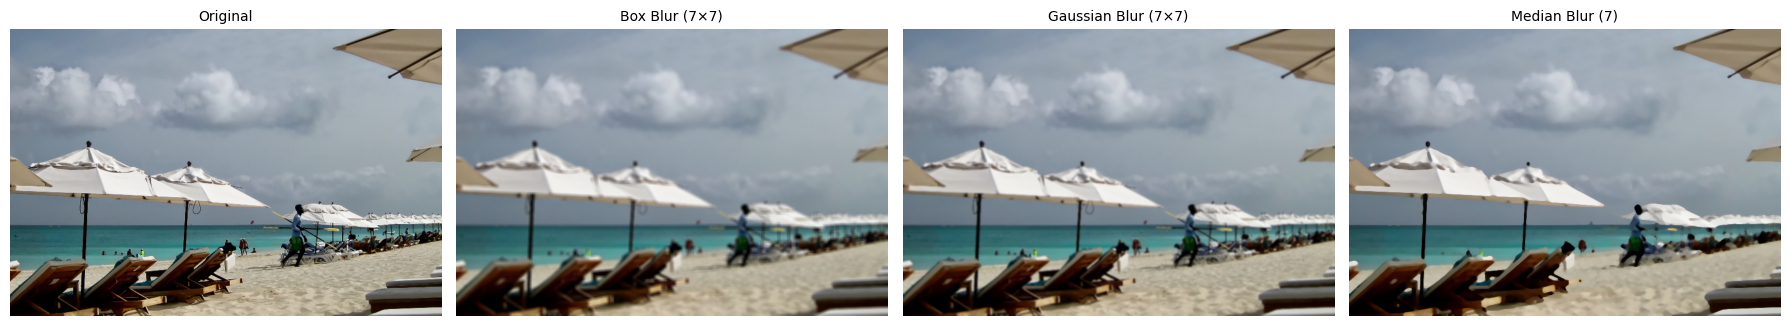

In [9]:
# Box blur — every pixel in the kernel has equal weight
box = cv2.blur(img, (7, 7))

# Gaussian blur — center pixel gets more weight, falls off like a bell curve
gaussian = cv2.GaussianBlur(img, (7, 7), 0)

# Median blur — replaces each pixel with the median of its neighbors
# Especially good at removing "salt and pepper" noise
median = cv2.medianBlur(img, 7)

show_images(
    [img, box, gaussian, median],
    ["Original", "Box Blur (7×7)", "Gaussian Blur (7×7)", "Median Blur (7)"],
    cols=4, figsize=(18, 5)
)

This cell compares the three blur types.

The box blur smooths the image evenly, so the whole picture becomes softer.  The Gaussian blur looks more natural because nearby pixels affect each other more than farther ones, so edges soften without looking as harsh. The median blur behaves differently because it replaces each pixel with the middle value of nearby pixels, which helps keep some edges stronger than the other two. This made it easier to see why Gaussian blur is often used more than box blur, while median blur is better when you want to reduce noise without destroying edges as much.


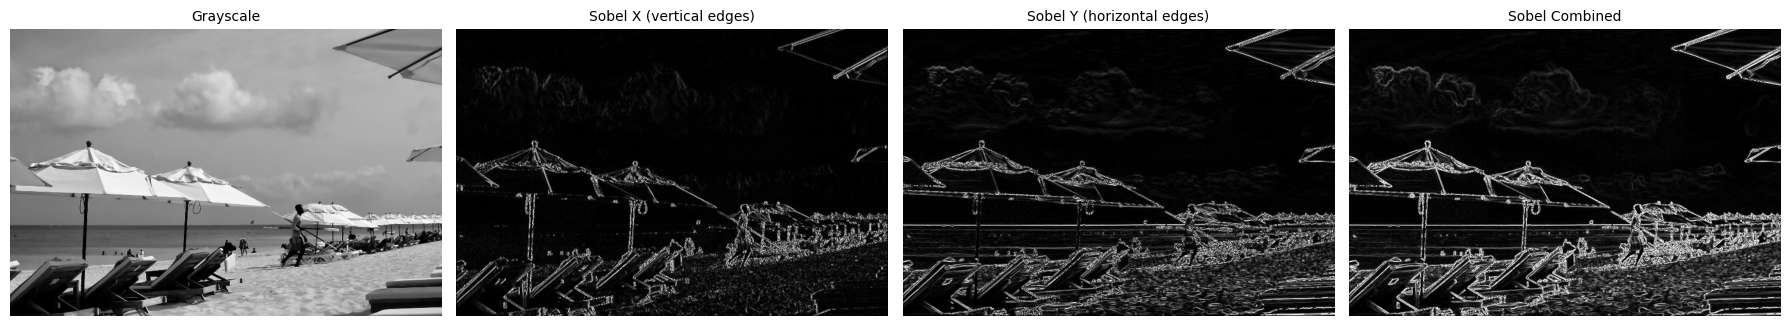

In [10]:
# Sobel in the X direction — detects vertical edges
sobel_x = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
sobel_x_abs = np.uint8(np.absolute(sobel_x))

# Sobel in the Y direction — detects horizontal edges
sobel_y = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
sobel_y_abs = np.uint8(np.absolute(sobel_y))

# Combined magnitude
sobel_combined = cv2.bitwise_or(sobel_x_abs, sobel_y_abs)

show_images(
    [gray, sobel_x_abs, sobel_y_abs, sobel_combined],
    ["Grayscale", "Sobel X (vertical edges)", "Sobel Y (horizontal edges)", "Sobel Combined"],
    cols=4, figsize=(18, 5)
)

This cell applies Sobel edge detection in two directions. It separates vertical edges from horizontal edges so it is easier to see which parts of the image stand out in each direction.


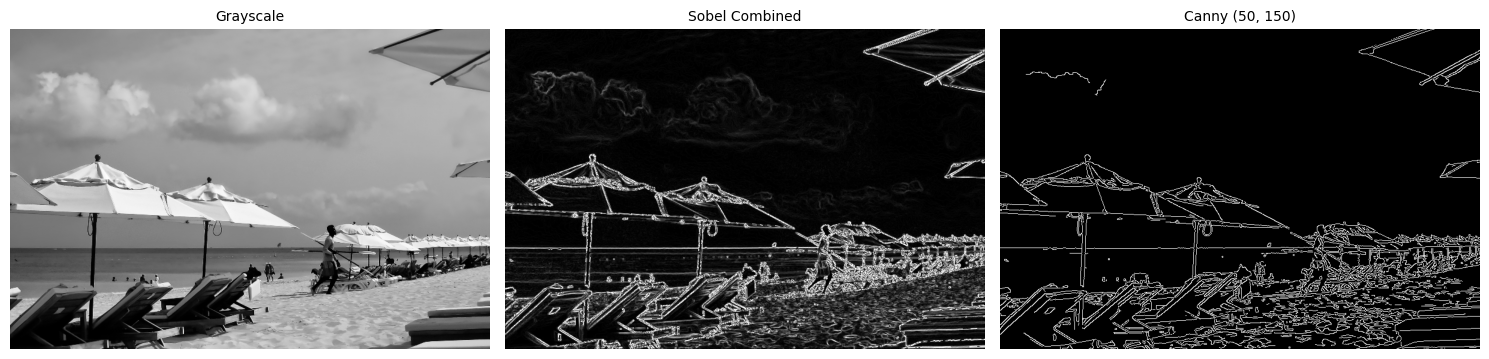

In [11]:
# Canny uses two thresholds to decide what counts as an "edge"
# Low threshold: weak edges below this are discarded
# High threshold: strong edges above this are kept
# Edges between the two are kept only if connected to a strong edge

canny = cv2.Canny(gray, threshold1=50, threshold2=150)

show_images(
    [gray, sobel_combined, canny],
    ["Grayscale", "Sobel Combined", "Canny (50, 150)"],
    cols=3, figsize=(15, 5)
)

Sobel X highlights vertical edges because it detects changes from left to right, which makes upright objects and boundaries stand out more. Sobel Y highlights horizontal edges because it detects changes from top to bottom, so the shoreline and horizon are easier to see there. The combined Sobel result shows both directions together, but Canny gives a cleaner and more focused edge map because it removes more weak noise and keeps stronger connected boundaries. In this image, Canny makes the main edges easier to separate from the extra detail in the background.

This part showed me that Sobel is useful for understanding edge direction, but Canny is cleaner when you want a clearer final outline of the image.


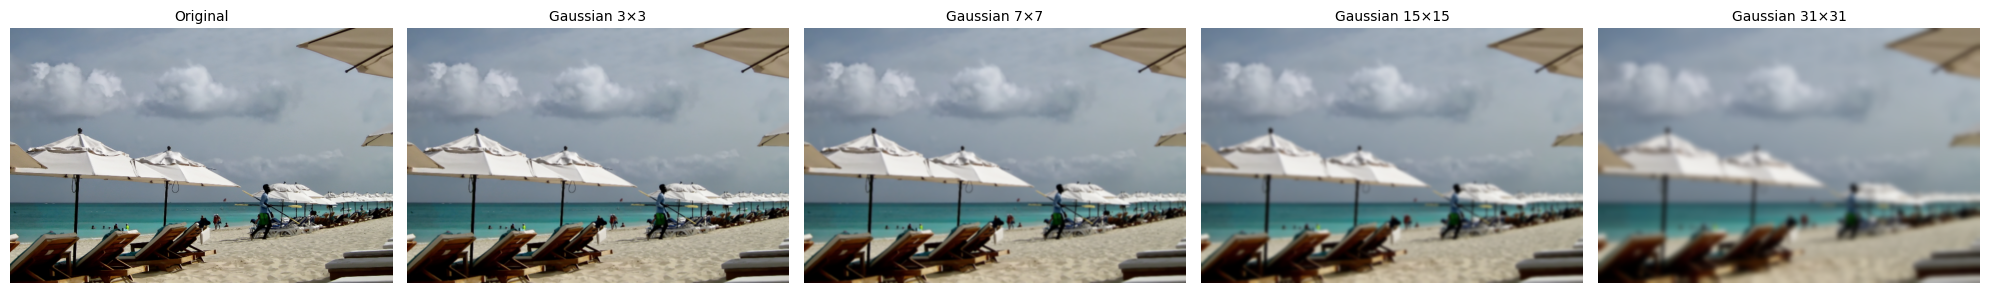

In [12]:
sizes = [3, 7, 15, 31]
blurred = [cv2.GaussianBlur(img, (s, s), 0) for s in sizes]

show_images(
    [img] + blurred,
    ["Original"] + [f"Gaussian {s}×{s}" for s in sizes],
    cols=5, figsize=(20, 5)
)

This cell changes the kernel size for Gaussian blur. It shows how a small kernel keeps more detail, while a larger kernel smooths the image much more aggressively.

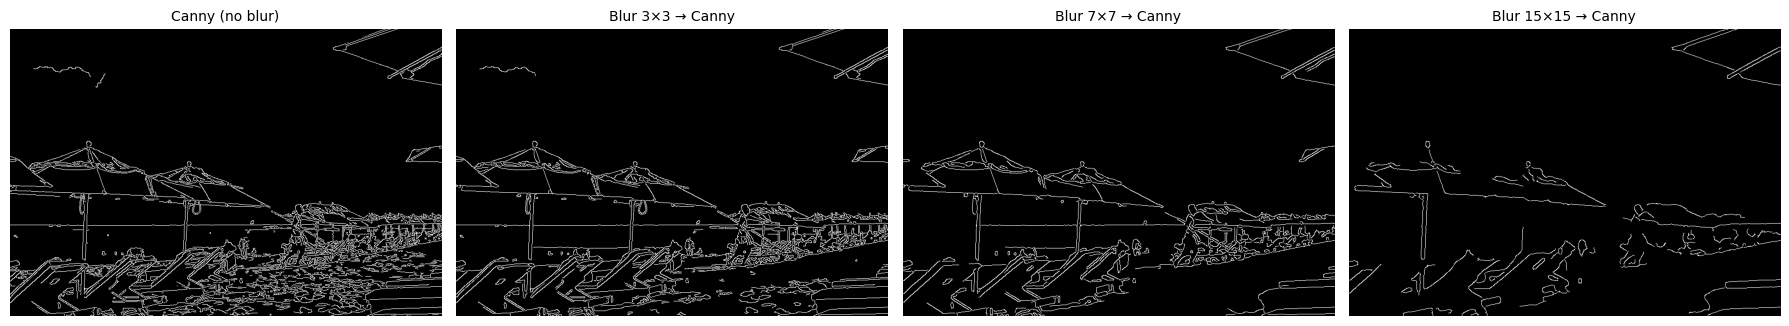

In [13]:
# Blur first with different kernel sizes, then apply Canny
# This shows how preprocessing affects edge detection

edge_results = []
edge_labels = []
for s in [0, 3, 7, 15]:
    if s == 0:
        blurred_gray = gray  # no blur
        label = "Canny (no blur)"
    else:
        blurred_gray = cv2.GaussianBlur(gray, (s, s), 0)
        label = f"Blur {s}×{s} → Canny"
    edges = cv2.Canny(blurred_gray, 50, 150)
    edge_results.append(edges)
    edge_labels.append(label)

show_images(edge_results, edge_labels, cols=4, figsize=(18, 5))

As the kernel size increases, the image becomes smoother and loses more fine detail. At the larger kernel sizes, some small objects and textures become hard to recognize. When blur is applied before Canny, the edge map becomes cleaner because some small noisy changes are removed first. The tradeoff is that too much blur can also erase useful edges. This made it clear why blur is often used before edge detection, but in moderation.